<a href="https://colab.research.google.com/github/SuMyatMon17/AI_Solution_Development_Project/blob/main/AI_Application_Development_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
db_path = '/content/gas_monitoring.db'
conn = sqlite3.connect(db_path)

# Try to read the table as before
df_raw = pd.read_sql('SELECT * FROM gas_monitoring', conn)

df_raw.head(20)


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity
5,afternoon,19.82,47.71,79.489742,616.349705,557.929178,779.316801,738.876591,664.886531,1.0,7241,Ventilation_Only,very_bright,Low Activity
6,night,20.04,48.42,118.293529,582.624643,474.777417,736.890795,694.939447,628.884980,1.0,6431,heating_active,bright,Low Activity
7,night,19.29,52.67,136.292680,574.121555,474.924866,721.380249,680.511012,622.275067,1.0,7963,maintenance_mode,bright,Moderate Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity


Data Overview

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [4]:
df_raw['Time of Day'] = df_raw['Time of Day'].str.lower().str.strip()
df_raw['HVAC Operation Mode'] = df_raw['HVAC Operation Mode'].str.lower().str.strip()
df_raw['Ambient Light Level'] = df_raw['Ambient Light Level'].str.lower().str.strip()
df_raw['Activity Level'] = df_raw['Activity Level'].str.lower().str.strip()


In [5]:
df_raw = df_raw.sort_values(
    by="Session ID",
    ascending=True
)

df_raw.head(50)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1885,afternoon,21.880000,44.23,114.993800,592.042931,434.778993,735.249639,702.156806,615.620900,NaN,1374,cooling_active,bright,high activity
1828,morning,18.020000,46.63,82.419737,610.153862,498.499105,764.572379,725.089410,678.069234,0.0,1374,off,moderate,low activity
9873,evening,20.050000,51.00,118.137116,586.135449,446.988854,NaN,632.391887,554.373709,2.0,1374,cooling_active,None,moderate activity
9875,night,18.540000,NaN,120.554285,591.421466,480.238613,747.631334,709.608994,646.301688,1.0,1374,off,very_bright,moderate activity
9823,evening,22.630000,46.11,21.376581,583.769443,463.879191,735.573011,681.830062,628.554769,1.0,1374,heating_active,bright,moderateactivity
2620,afternoon,17.450000,NaN,87.405254,612.108210,556.839594,NaN,741.225193,668.747077,0.0,1374,heating_active,very_bright,high activity
2645,afternoon,21.590000,44.75,109.822895,591.371294,432.757429,737.438899,694.116930,638.465106,1.0,1374,eco_mode,very_bright,moderate activity
2623,afternoon,17.730000,48.82,97.217427,602.672854,554.198154,769.269874,480.321243,687.863025,0.0,1374,cooling_active,moderate,moderate activity
2593,morning,28.483264,46.60,67.377484,615.405777,580.618470,783.753133,760.004229,711.328306,0.0,1374,eco_mode,very_dim,moderate activity
2594,morning,16.000000,47.07,72.193842,615.731314,611.643679,788.492289,768.972574,717.889514,0.0,1374,off,bright,moderate activity


Missing Data Values

In [6]:
df_raw.notnull()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1885,True,True,True,True,True,True,True,True,True,False,True,True,True,True
1828,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9873,True,True,True,True,True,True,False,True,True,True,True,True,False,True
9875,True,True,False,True,True,True,True,True,True,True,True,True,True,True
9823,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2422,True,True,False,True,True,True,True,True,True,True,True,True,True,True
404,True,True,True,True,True,True,True,True,True,False,True,True,True,True
31,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9980,True,True,True,True,True,True,True,True,True,False,True,True,True,True


In [7]:
df_raw.isnull().sum()

,0
Time of Day,0
Temperature,0
Humidity,1928
CO2_InfraredSensor,0
CO2_ElectroChemicalSensor,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,1410
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0
CO_GasSensor,834


Duplicate data

In [8]:
full_duplicates = df_raw.duplicated()

print(
    "Full row duplicates:",
    full_duplicates.sum()
)

df_raw[full_duplicates].head(20)

Full row duplicates: 223


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2353,morning,18.07,52.47,116.984140,596.032950,485.932116,762.102352,734.793427,656.202911,1.0,1374,heating_active,dim,low activity
6550,afternoon,21.59,44.75,109.822895,591.371294,432.757429,737.438899,694.116930,638.465106,1.0,1374,eco_mode,very_bright,moderate activity
1137,morning,17.99,52.41,122.561974,592.362155,471.020247,743.116299,688.897073,626.213930,1.0,1374,cooling_active,bright,moderate activity
8809,morning,17.57,53.11,122.855690,592.614287,500.585812,751.279196,701.155042,649.035866,1.0,1374,eco_mode,very_dim,low activity
2531,morning,17.90,52.62,114.943077,592.598601,491.368258,754.609372,728.144610,653.696325,1.0,1374,ventilation_only,very_bright,low activity
8200,morning,16.80,49.98,102.504902,596.979672,512.225326,762.622265,706.939271,660.867415,1.0,1374,heating_active,very_bright,moderate activity
2624,afternoon,17.56,49.09,89.444437,606.028654,556.101782,766.360175,731.305826,677.078106,0.0,1374,cooling_active,bright,low activity
7305,night,18.88,51.67,123.873710,588.731538,482.444130,732.393147,672.252629,601.851890,1.0,1374,cooling_active,bright,high activity
2636,afternoon,19.92,47.81,115.489467,593.443170,433.043947,729.092451,683.163966,639.949618,0.0,1374,ventilation_only,bright,low activity
2611,afternoon,17.65,NaN,86.974478,607.000272,563.175713,776.174485,746.993438,687.678051,0.0,1374,off,very_bright,moderate activity


In [9]:
# rows involved in exact duplicate groups
dup_mask = df_raw.duplicated(
    subset=list(df_raw.columns),
    keep=False
)

all_exact_duplicates = df_raw[dup_mask].copy()

# sort so identical rows appear next to each other
all_exact_duplicates = all_exact_duplicates.sort_values(
    by=list(df_raw.columns)
)

print("Rows involved in exact duplicate groups:", len(all_exact_duplicates))

all_exact_duplicates

Rows involved in exact duplicate groups: 442


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
3470,afternoon,16.56,45.82,63.558315,615.347358,632.891693,789.609160,768.964066,707.689461,0.0,3418,off,bright,moderate activity
7922,afternoon,16.56,45.82,63.558315,615.347358,632.891693,789.609160,768.964066,707.689461,0.0,3418,off,bright,moderate activity
3468,afternoon,16.70,46.32,65.292783,619.759591,612.966805,782.441940,750.287654,721.181693,0.0,3418,maintenance_mode,very_bright,low activity
6365,afternoon,16.70,46.32,65.292783,619.759591,612.966805,782.441940,750.287654,721.181693,0.0,3418,maintenance_mode,very_bright,low activity
3464,afternoon,16.76,46.47,67.115142,619.615391,606.667323,786.321646,751.661839,721.744488,0.0,3418,maintenance_mode,bright,moderate activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5059,night,22.42,51.17,121.736227,572.551756,429.466524,707.737732,654.018368,599.623964,1.0,4507,cooling_active,very_bright,low activity
3411,night,22.46,53.89,128.841981,549.510544,466.706268,705.459465,661.439758,594.877674,1.0,3592,heating_active,very_bright,low activity
4006,night,22.46,53.89,128.841981,549.510544,466.706268,705.459465,661.439758,594.877674,1.0,3592,heating_active,very_bright,low activity
4134,night,23.19,48.92,121.393677,568.186457,386.093867,681.539270,637.299590,555.150185,3.0,7395,maintenance_mode,very_bright,low activity


In [10]:
print(
    "Rows to remove:",
    df_raw.duplicated(
        subset=list(df_raw.columns),
        keep="first"
    ).sum()
)

Rows to remove: 223


Outliers handling

In [11]:
df_raw.describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


In [12]:
numerical_cols = df_raw.select_dtypes(include=np.number).columns

outliers_count = {}
for col in numerical_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers for the current column
    col_outliers = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)]
    outliers_count[col] = len(col_outliers)

print("Number of outliers per numerical column (using IQR method):\n", outliers_count)

Number of outliers per numerical column (using IQR method):
 {'Temperature': 994, 'Humidity': 414, 'CO2_InfraredSensor': 805, 'CO2_ElectroChemicalSensor': 5, 'MetalOxideSensor_Unit1': 609, 'MetalOxideSensor_Unit2': 160, 'MetalOxideSensor_Unit3': 820, 'MetalOxideSensor_Unit4': 293, 'CO_GasSensor': 75, 'Session ID': 0}


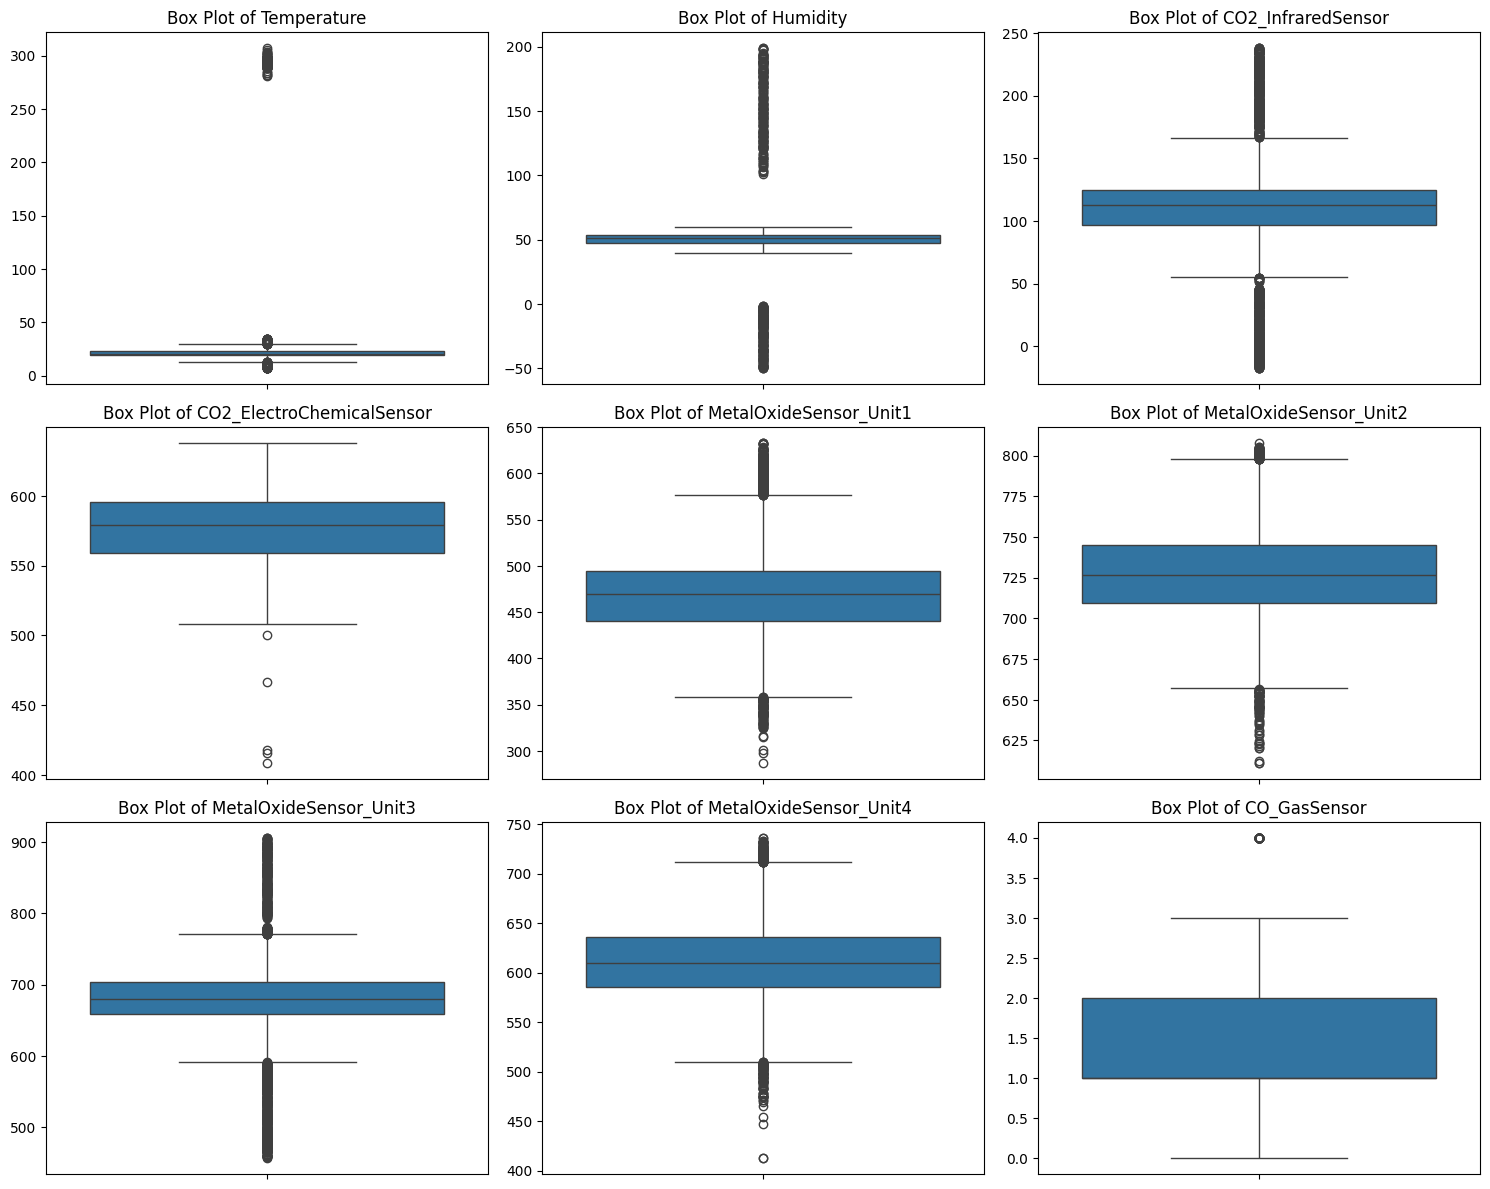

In [13]:

numerical_cols_with_outliers = [col for col, count in outliers_count.items() if count > 0]

if not numerical_cols_with_outliers:
    print("No numerical columns with outliers were identified based on the previous calculation.")
else:
    num_plots = len(numerical_cols_with_outliers)
    num_cols = 3 # Number of columns for subplots
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate number of rows needed

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten() # Flatten the array of axes for easy iteration

    for i, col in enumerate(numerical_cols_with_outliers):
        sns.boxplot(y=df_raw[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel('') # Remove y-label to avoid clutter, title is sufficient

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Categorical Data Overview

In [14]:
categorical_cols = df_raw.select_dtypes(include='object').columns

if not categorical_cols.empty:
    for col in categorical_cols:
        print(f"\n--- Categorical Column: {col} ---")
        print(df_raw[col].value_counts())
        print(f"Number of unique values: {df_raw[col].nunique()}")
else:
    print("No categorical columns found in the DataFrame.")


--- Categorical Column: Time of Day ---
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64
Number of unique values: 4

--- Categorical Column: HVAC Operation Mode ---
HVAC Operation Mode
cooling_active      1728
maintenance_mode    1703
eco_mode            1673
heating_active      1660
off                 1652
ventilation_only    1584
Name: count, dtype: int64
Number of unique values: 6

--- Categorical Column: Ambient Light Level ---
Ambient Light Level
very_bright    3387
bright         2697
moderate       1463
dim             864
very_dim        535
Name: count, dtype: int64
Number of unique values: 5

--- Categorical Column: Activity Level ---
Activity Level
low activity         5244
moderate activity    2812
high activity        1095
moderateactivity      326
low_activity          285
lowactivity           238
Name: count, dtype: int64
Number of unique values: 6


/tmp/ipykernel_3773/563502384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Time of Day", data=df_raw, palette="viridis")


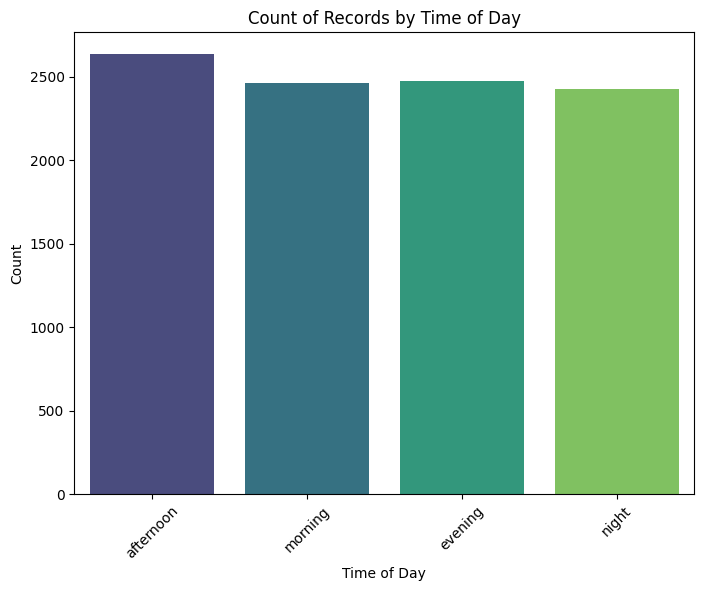

In [15]:
# --- Bar plot for Time of Day counts ---
plt.figure(figsize=(8, 6))
sns.countplot(x="Time of Day", data=df_raw, palette="viridis")

plt.title("Count of Records by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3773/3540038132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="HVAC Operation Mode", data=df_raw, palette="inferno")


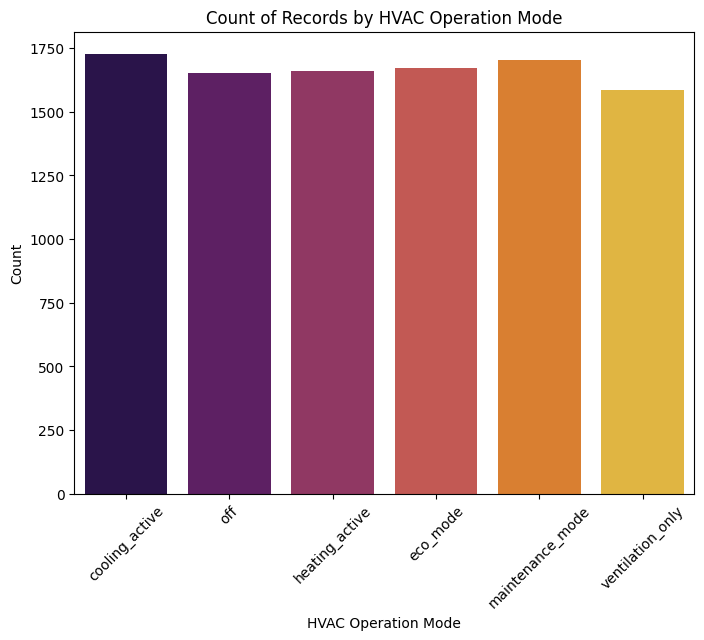

In [16]:
# --- Bar plot for Time of Day counts ---
plt.figure(figsize=(8, 6))
sns.countplot(x="HVAC Operation Mode", data=df_raw, palette="inferno")

plt.title("Count of Records by HVAC Operation Mode")
plt.xlabel("HVAC Operation Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3773/2211562272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Ambient Light Level", data=df_raw, palette="pastel")


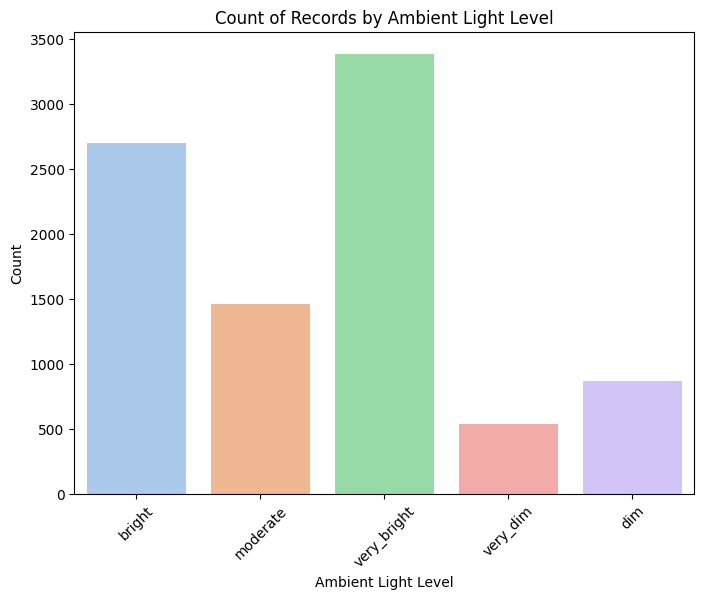

In [17]:
# --- Bar plot for Time of Day counts ---
plt.figure(figsize=(8, 6))
sns.countplot(x="Ambient Light Level", data=df_raw, palette="pastel")

plt.title("Count of Records by Ambient Light Level")
plt.xlabel("Ambient Light Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3773/1858558983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Activity Level", data=df_raw, palette="plasma")


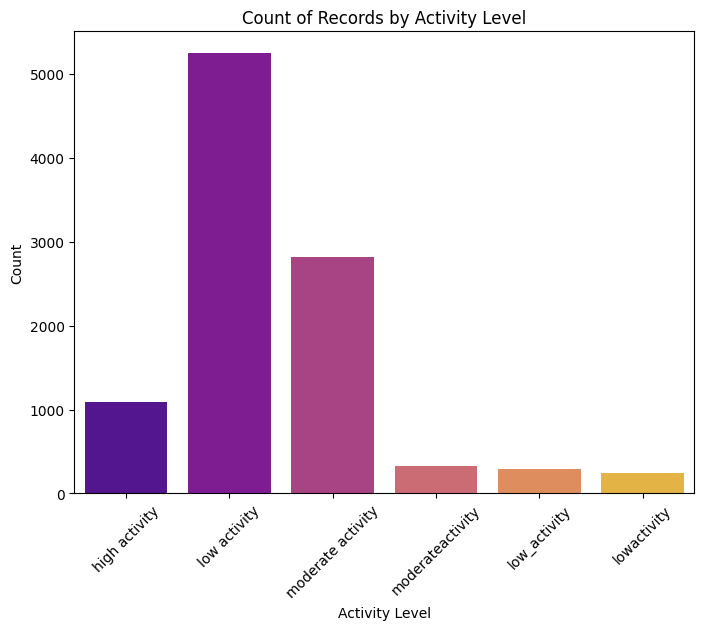

In [20]:
# --- Bar plot for Time of Day counts ---
plt.figure(figsize=(8, 6))
sns.countplot(x="Activity Level", data=df_raw, palette="plasma")

plt.title("Count of Records by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

 Categorizing Numerical Sensor Data


In [19]:
# Define the bins and labels for categorization
bins = [-float('inf'), 0, 100, float('inf')]
labels = ['below 0', '0-100', 'above 100']

# Categorize Temperature
df_raw['Temperature_Range'] = pd.cut(df_raw['Temperature'], bins=bins, labels=labels, right=False)

# Categorize Humidity
df_raw['Humidity_Range'] = pd.cut(df_raw['Humidity'], bins=bins, labels=labels, right=False)

# Categorize CO2_InfraredSensor
df_raw['CO2_InfraredSensor_Range'] = pd.cut(df_raw['CO2_InfraredSensor'], bins=bins, labels=labels, right=False)

print("--- Temperature Range Counts ---")
print(df_raw['Temperature_Range'].value_counts().sort_index())

print("\n--- Humidity Range Counts ---")
print(df_raw['Humidity_Range'].value_counts().sort_index())

print("\n--- CO2_InfraredSensor Range Counts ---")
print(df_raw['CO2_InfraredSensor_Range'].value_counts().sort_index())

--- Temperature Range Counts ---
Temperature_Range
below 0         0
0-100        9205
above 100     795
Name: count, dtype: int64

--- Humidity Range Counts ---
Humidity_Range
below 0       207
0-100        7658
above 100     207
Name: count, dtype: int64

--- CO2_InfraredSensor Range Counts ---
CO2_InfraredSensor_Range
below 0       113
0-100        2680
above 100    7207
Name: count, dtype: int64


After cleaning in .py, data correlation and visualisation